In [2]:
# import optuna
# from optuna.samplers import TPESampler
import warnings

import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import math
from collections import defaultdict
import seaborn as sns
from catboost import CatBoostClassifier, CatBoostRegressor
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import Lasso, Ridge, RidgeCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from xgboost import XGBClassifier
from pathlib import Path

warnings.filterwarnings("ignore")

In [3]:
dataset = 'hosp_discharge_radio' # 'hosp_discharge' / 'hosp_only' / 'hosp_discharge_radio'

In [4]:
hosp_discharge_radio_path = "../data/processed/final_hosp_discharge_radio.csv"
hosp_discharge_path = "../data/processed/final_hosp_discharge.csv"
hosp_only_path = "../data/processed/final_hosp_dataset.csv"

if dataset == 'hosp_and_discharge':
    hosp_df = pd.read_csv(hosp_discharge_path)
    hosp_df.info()
elif dataset == 'hosp_only':
    hosp_df = pd.read_csv(hosp_only_path)
    hosp_df.info()
elif dataset == 'hosp_discharge_radio':
    hosp_df = pd.read_csv(hosp_discharge_radio_path)
    hosp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36899 entries, 0 to 36898
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   subject_id          36899 non-null  int64  
 1   gender              36899 non-null  object 
 2   anchor_age          36899 non-null  int64  
 3   label               36899 non-null  int64  
 4   has_labs            36899 non-null  int64  
 5   has_omr             36899 non-null  int64  
 6   has_charte          36899 non-null  int64  
 7   Anion_Gap_mean      35184 non-null  float64
 8   Bicarbonate_mean    35187 non-null  float64
 9   Chloride_mean       35228 non-null  float64
 10  Creatinine_mean     35694 non-null  float64
 11  Potassium_mean      35246 non-null  float64
 12  Sodium_mean         35237 non-null  float64
 13  Urea_Nitrogen_mean  35527 non-null  float64
 14  Glucose_mean        35503 non-null  float64
 15  Glucose_std         31035 non-null  float64
 16  Gluc

In [5]:
# config
RANDOM_STATE = 42
TEST_SIZE = 0.2  # 20% test

# columns you may want to include in composite stratify key (if Option B)
AGE_BINS = [0, 30, 50, 65, 80, 120]   # adjust for your cohort
BMI_BINS = [0, 18.5, 25, 30, 100]     # adjust if you have bmi_mean

# ---------------------------------------------------------------------
# Option A: simple stratify on label (fast, robust)
# ---------------------------------------------------------------------
def split_stratify_label(df, test_size=TEST_SIZE, random_state=RANDOM_STATE, label_col='label'):
    # ensure no NaNs in label
    if df[label_col].isna().any():
        raise ValueError(f"Label column '{label_col}' contains NaNs. Fill or drop them first.")
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        stratify=df[label_col]
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

# ---------------------------------------------------------------------
# Option B: composite stratify key (recommended for better balance)
# ---------------------------------------------------------------------
def make_composite_strata(df,
                          label_col='label',
                          gender_col='gender',
                          age_col='anchor_age',
                          bmi_col='bmi_mean',
                          has_omr_col='has_omr',
                          age_bins=AGE_BINS,
                          bmi_bins=BMI_BINS,
                          min_group_size=50):
    d = df.copy()

    # 1) label to string
    d['_lab'] = d[label_col].astype(str)

    # 2) gender (fill NAs)
    if gender_col in d.columns:
        d['_g'] = d[gender_col].fillna('UNK').astype(str)
    else:
        d['_g'] = 'UNK'

    # 3) age bins
    if age_col in d.columns:
        d['_agebin'] = pd.cut(d[age_col].fillna(-1), bins=age_bins, labels=False, include_lowest=True).astype('object')
        d['_agebin'] = d['_agebin'].fillna('ageNA').astype(str)
    else:
        d['_agebin'] = 'ageNA'

    # 4) bmi bins (if available) OR has_omr
    if bmi_col in d.columns:
        d['_bmibin'] = pd.cut(d[bmi_col].fillna(-1), bins=bmi_bins, labels=False, include_lowest=True).astype('object')
        d['_bmibin'] = d['_bmibin'].fillna('bmiNA').astype(str)
    elif has_omr_col in d.columns:
        d['_bmibin'] = d[has_omr_col].fillna(0).astype(int).astype(str)
    else:
        d['_bmibin'] = 'bmiNA'

    # composite key
    d['_strata'] = d['_lab'] + '_' + d['_g'] + '_' + d['_agebin'].astype(str) + '_' + d['_bmibin'].astype(str)

    # collapse rare groups with count < min_group_size into 'RARE'
    group_counts = d['_strata'].value_counts()
    rare_groups = set(group_counts[group_counts < min_group_size].index)
    d['_strata_collapsed'] = d['_strata'].apply(lambda x: 'RARE' if x in rare_groups else x)

    # final check - no nulls
    if d['_strata_collapsed'].isna().any():
        d['_strata_collapsed'] = d['_strata_collapsed'].fillna('RARE')

    return d['_strata_collapsed']

def split_stratify_composite(df, test_size=TEST_SIZE, random_state=RANDOM_STATE, **kwargs):
    strata = make_composite_strata(df, **kwargs)
    # ensure there is no group with a single sample (train_test_split will fail)
    vc = strata.value_counts()
    if (vc == 1).any():
        # reduce min_group_size or fallback to label stratify
        print("Warning: some strata have only 1 sample. Falling back to label stratify.")
        return split_stratify_label(df, test_size=test_size, random_state=random_state, label_col=kwargs.get('label_col','label'))

    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        stratify=strata
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

# ---------------------------------------------------------------------
# Example usage:
# ---------------------------------------------------------------------

# 1) Quick distribution stats helper
def compare_distributions(train_df, test_df, cat_cols=None, num_cols=None):
    cat_cols = cat_cols or []
    num_cols = num_cols or []
    print("Categorical columns distribution (train vs test):")
    for c in cat_cols:
        print(f"\n-- {c} --")
        t = train_df[c].value_counts(normalize=True, dropna=False).sort_index()
        s = test_df[c].value_counts(normalize=True, dropna=False).sort_index()
        df_compare = pd.concat([t, s], axis=1, keys=['train', 'test']).fillna(0)
        print(df_compare)

    print("\nNumerical columns summary (train vs test):")
    for c in num_cols:
        print(f"\n-- {c} --")
        print(" train: mean {:.3f}, std {:.3f}".format(train_df[c].mean(), train_df[c].std()))
        print(" test : mean {:.3f}, std {:.3f}".format(test_df[c].mean(), test_df[c].std()))




In [6]:
# ---------------------------------------------------------------------
# Run split (choose method)
# ---------------------------------------------------------------------
# Option A:
train_df, test_df = split_stratify_label(hosp_df, test_size=0.2, label_col='label')

'''
# Option B (recommended):
train_df, test_df = split_stratify_composite(
    hosp_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    label_col='label',
    gender_col='gender',
    age_col='anchor_age',
    bmi_col='bmi_mean',        # if you don't have bmi_mean, this argument will be ignored
    has_omr_col='has_omr',
    age_bins=AGE_BINS,
    bmi_bins=BMI_BINS,
    min_group_size=50         # tune (larger -> more groups collapsed into RARE)
)
'''

# 2) Quick checks
compare_distributions(
    train_df, test_df,
    cat_cols=['label','gender','has_omr','has_labs','has_charte', 'htn_any_mention'],
    num_cols=['anchor_age','bmi_mean','Creatinine_mean', 'htn_mention_count']  # adjust numeric cols present in your dataset
)

Categorical columns distribution (train vs test):

-- label --
          train      test
label                    
0      0.499035  0.499051
1      0.500965  0.500949

-- gender --
           train      test
gender                    
F       0.524273  0.524255
M       0.475727  0.475745

-- has_omr --
            train      test
has_omr                    
0        0.219249  0.215718
1        0.780751  0.784282

-- has_labs --
             train      test
has_labs                    
0         0.026966  0.026423
1         0.973034  0.973577

-- has_charte --
            train  test
has_charte             
1             1.0   1.0

-- htn_any_mention --
                    train      test
htn_any_mention                    
True             0.389173  0.393496
NaN              0.610827  0.606504

Numerical columns summary (train vs test):

-- anchor_age --
 train: mean 55.770, std 20.264
 test : mean 55.266, std 20.277

-- bmi_mean --
 train: mean 35.386, std 440.723
 test : mean 31.207,

Plotting distributions for 22 numeric features...


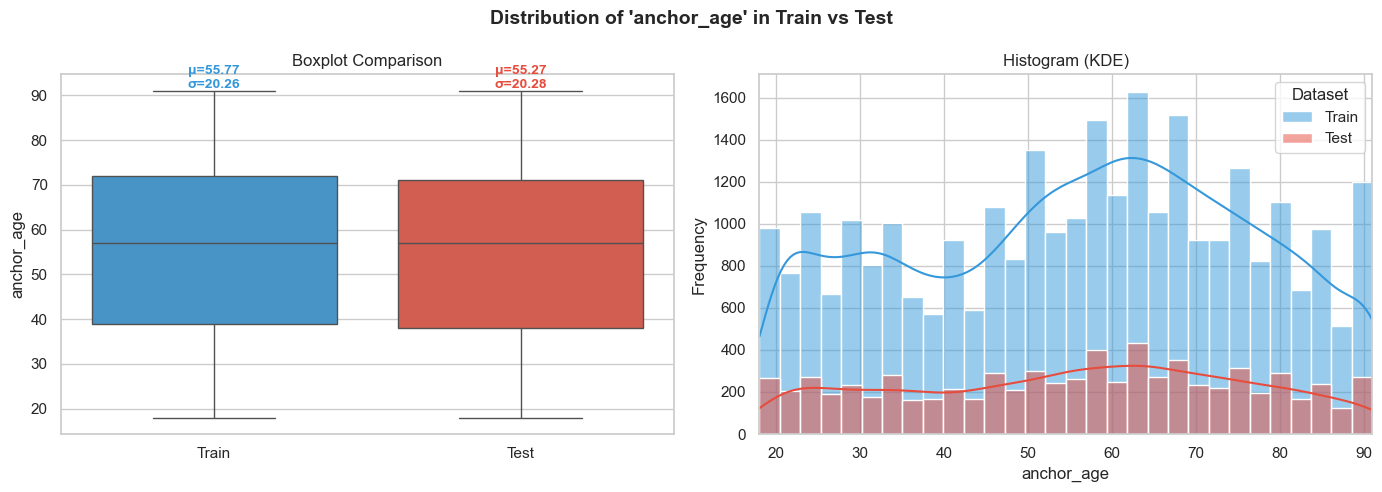

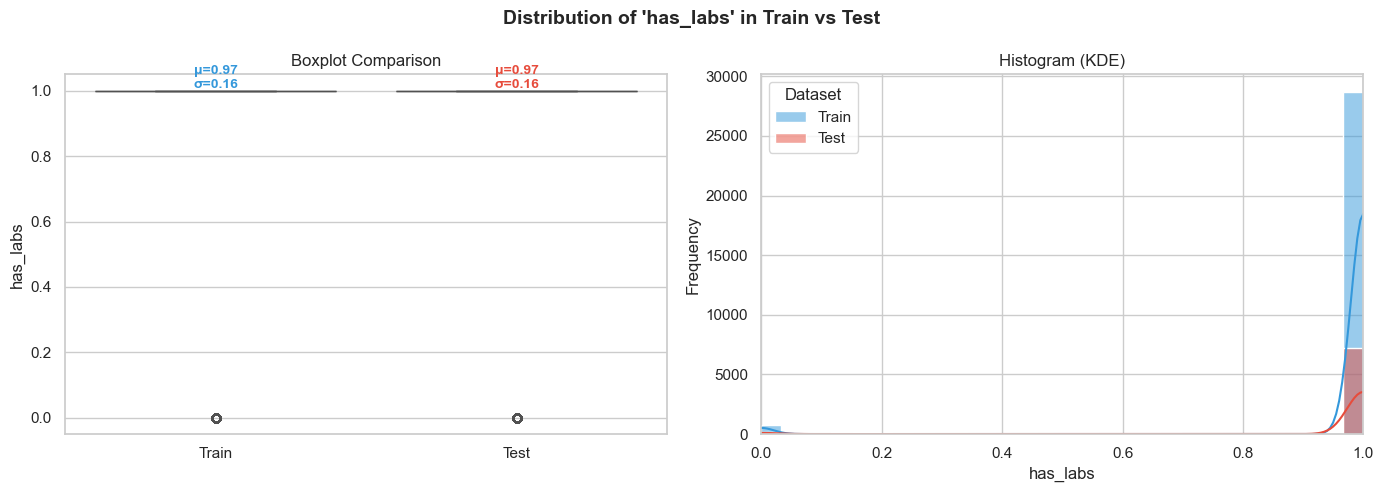

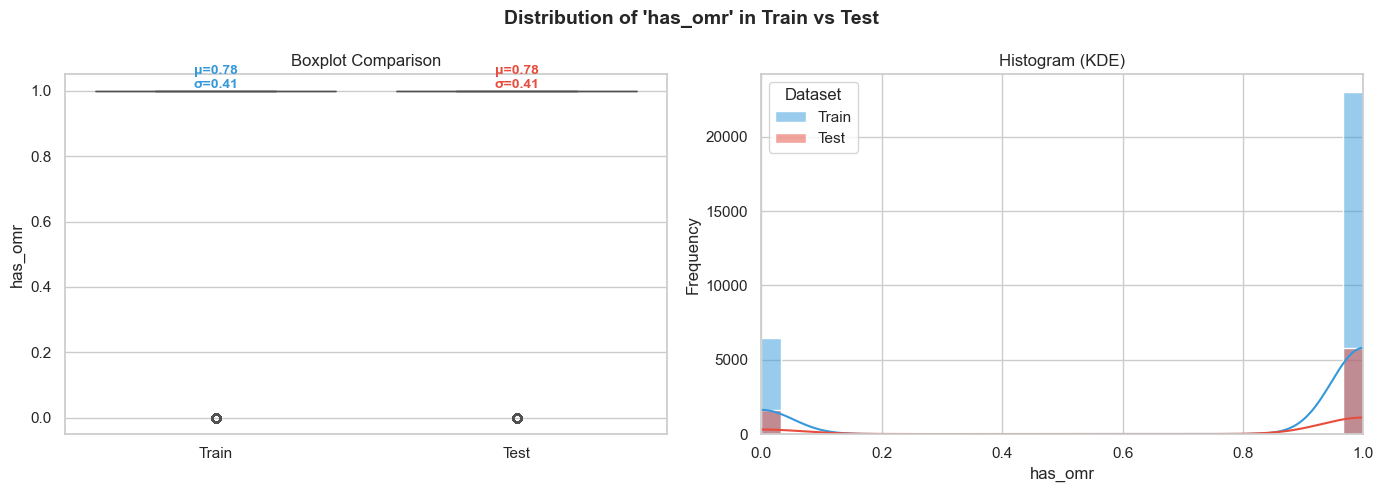

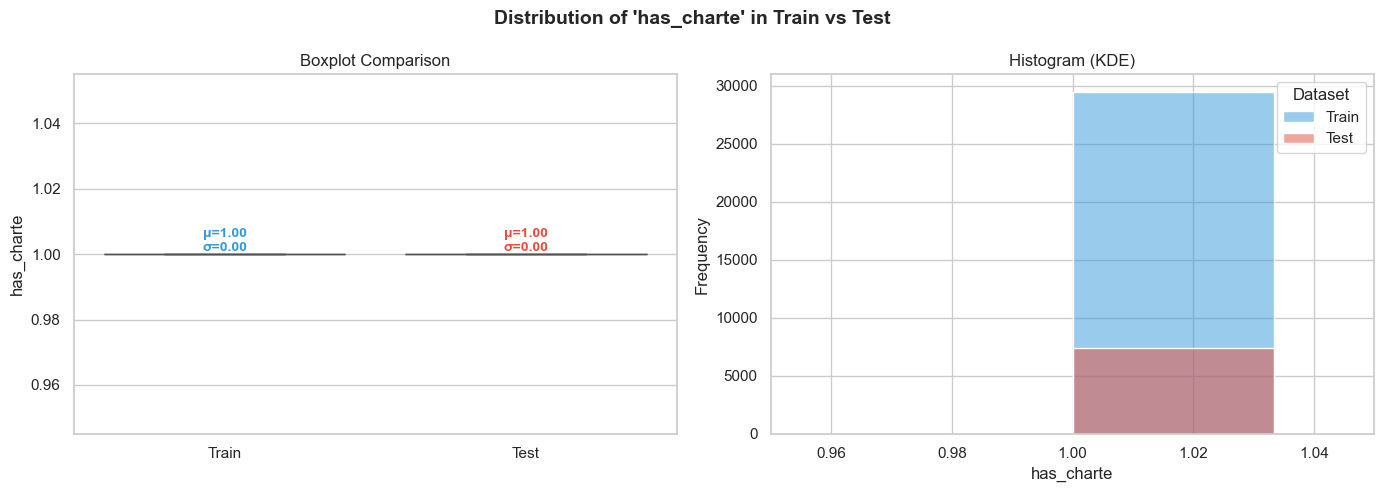

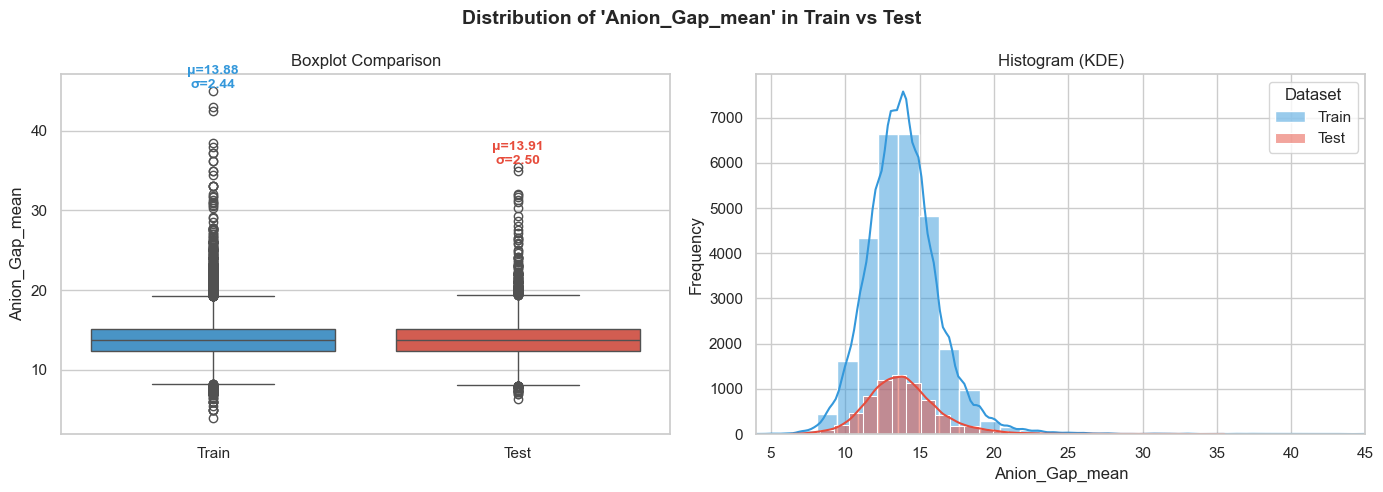

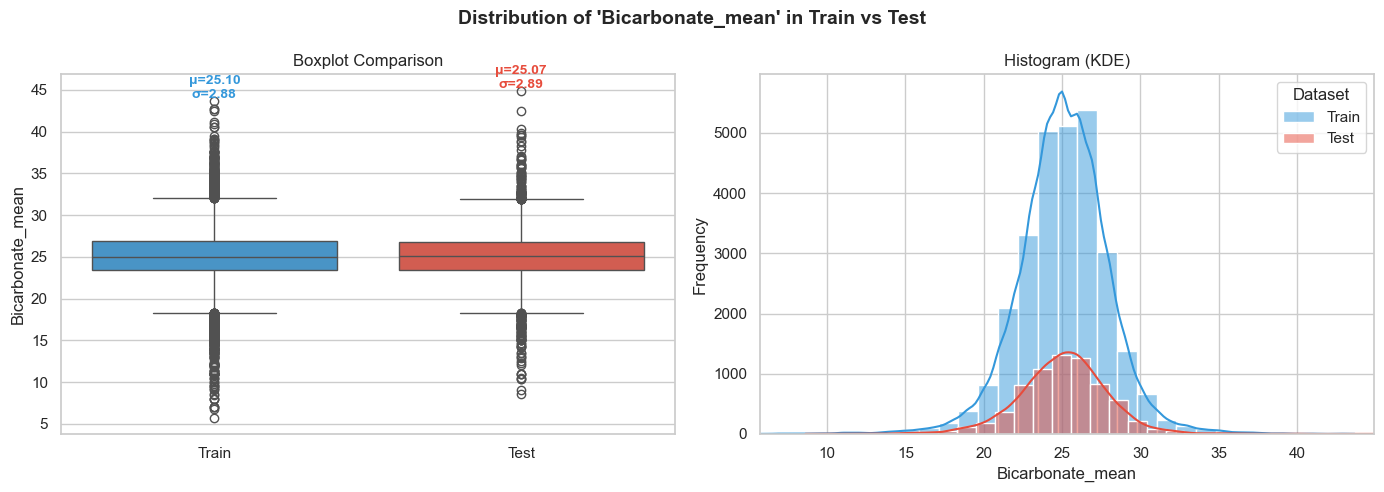

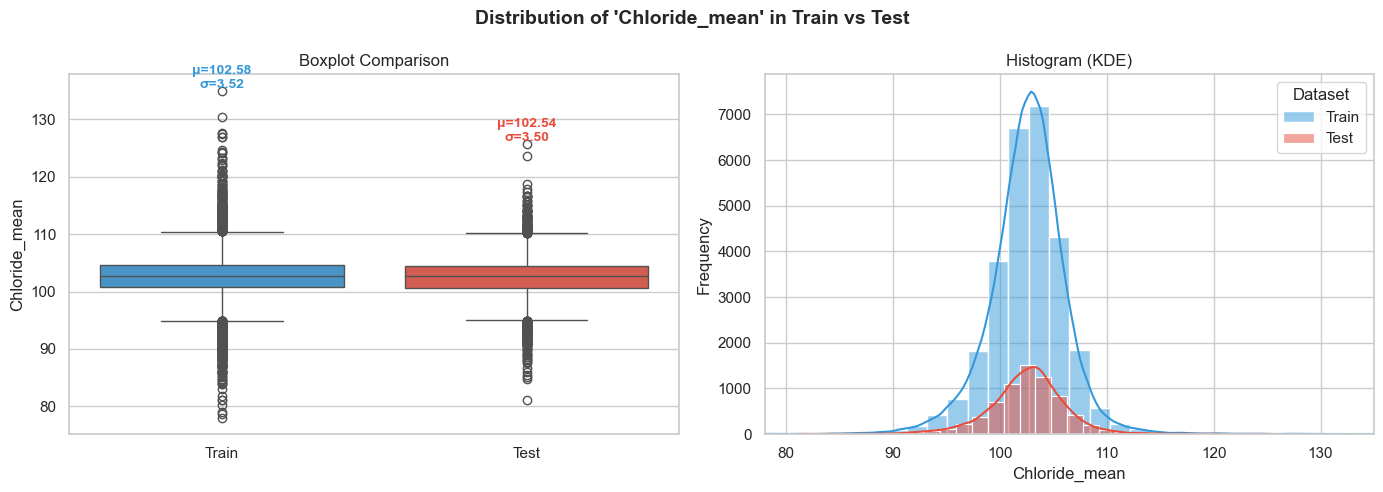

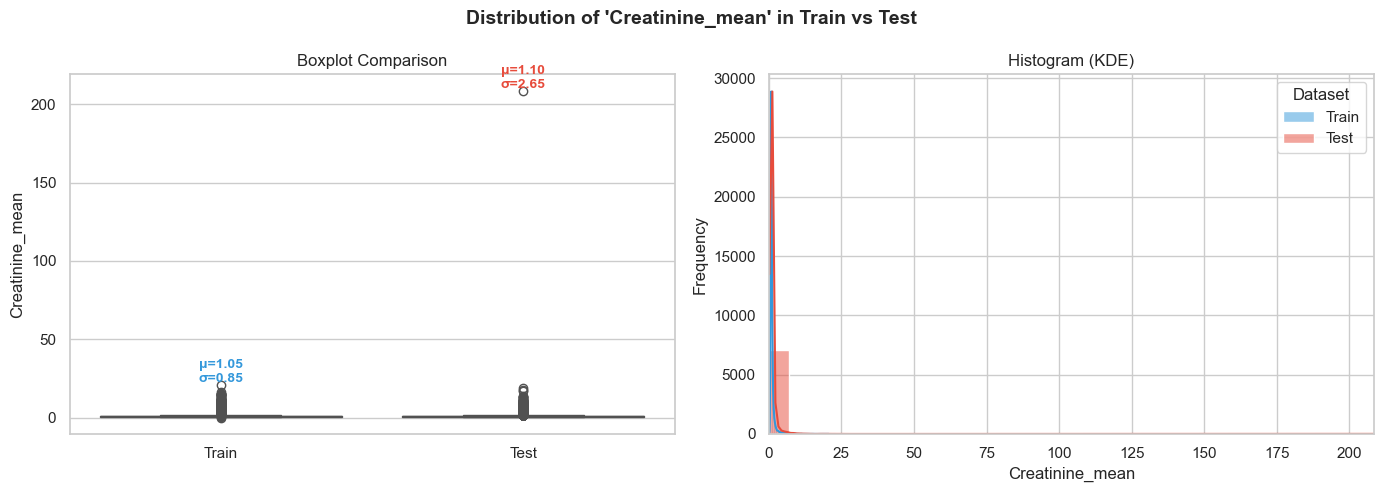

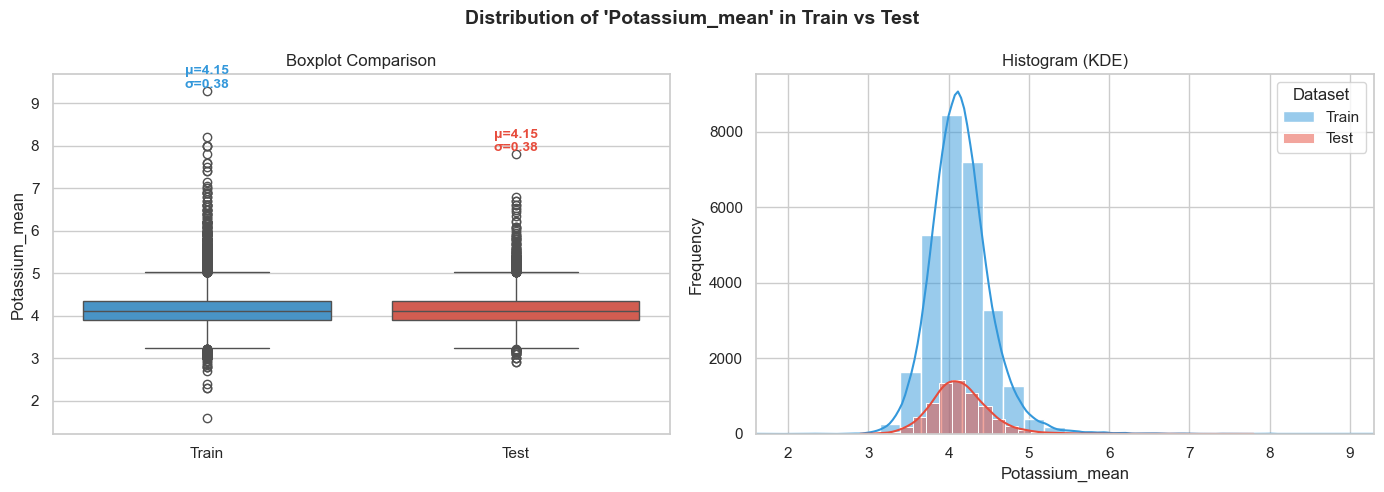

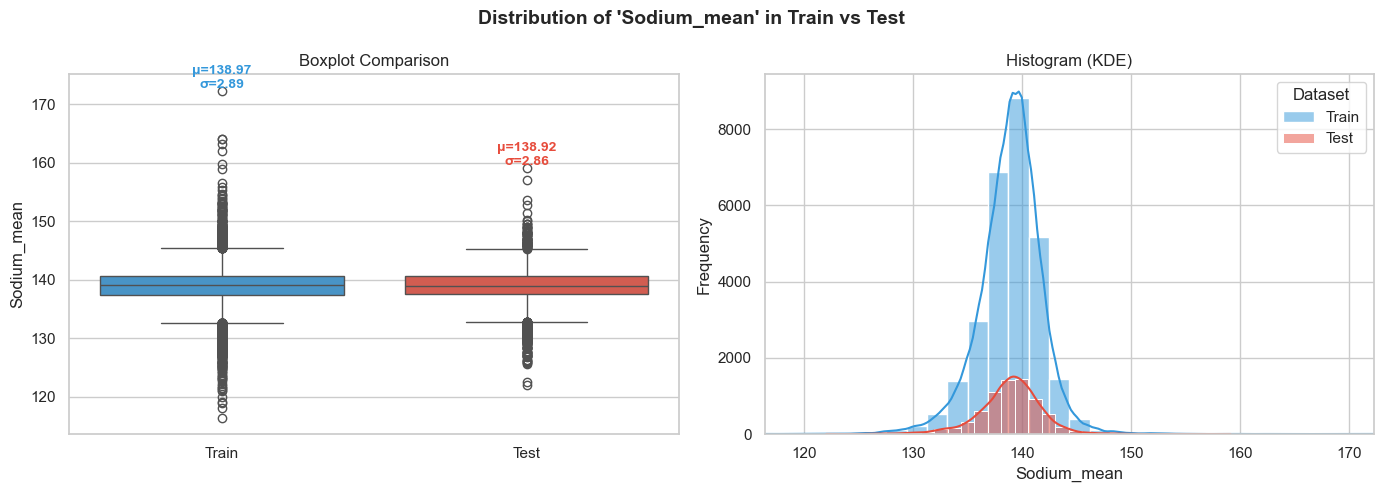

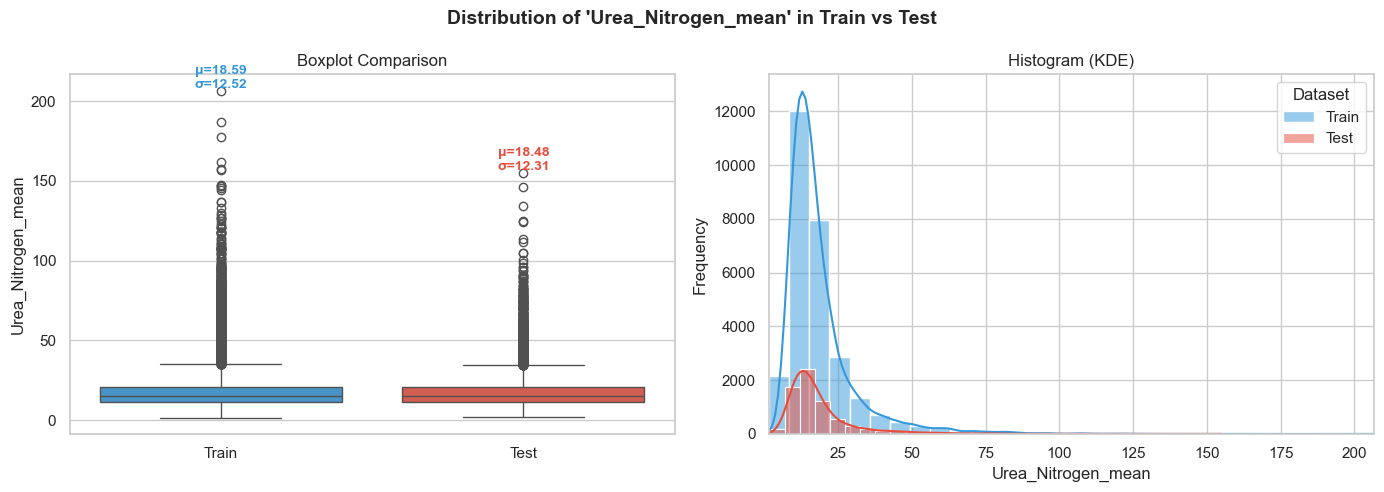

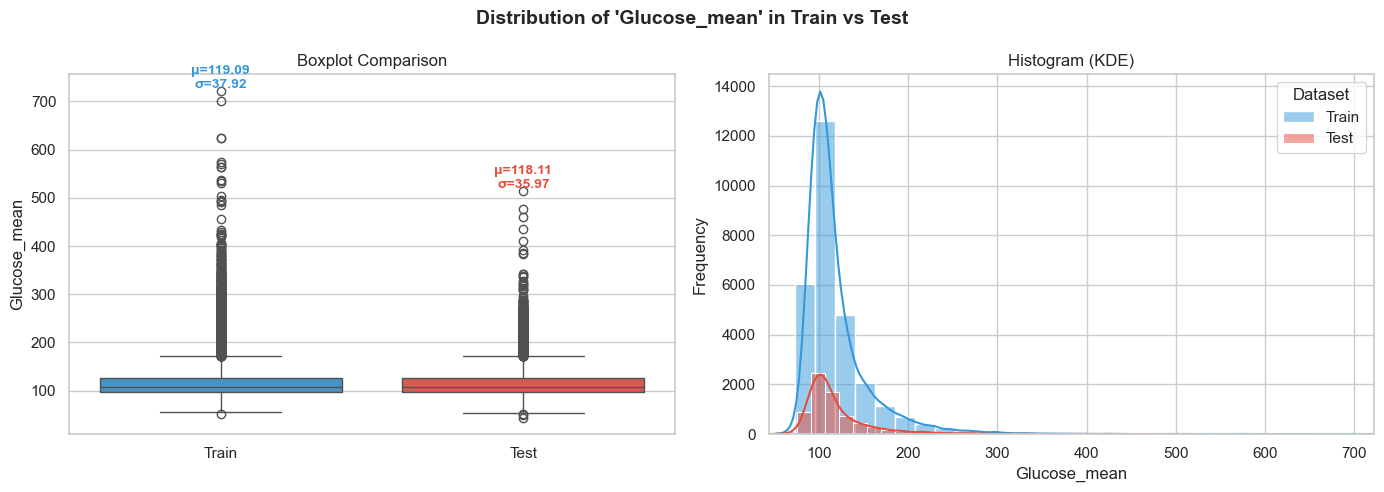

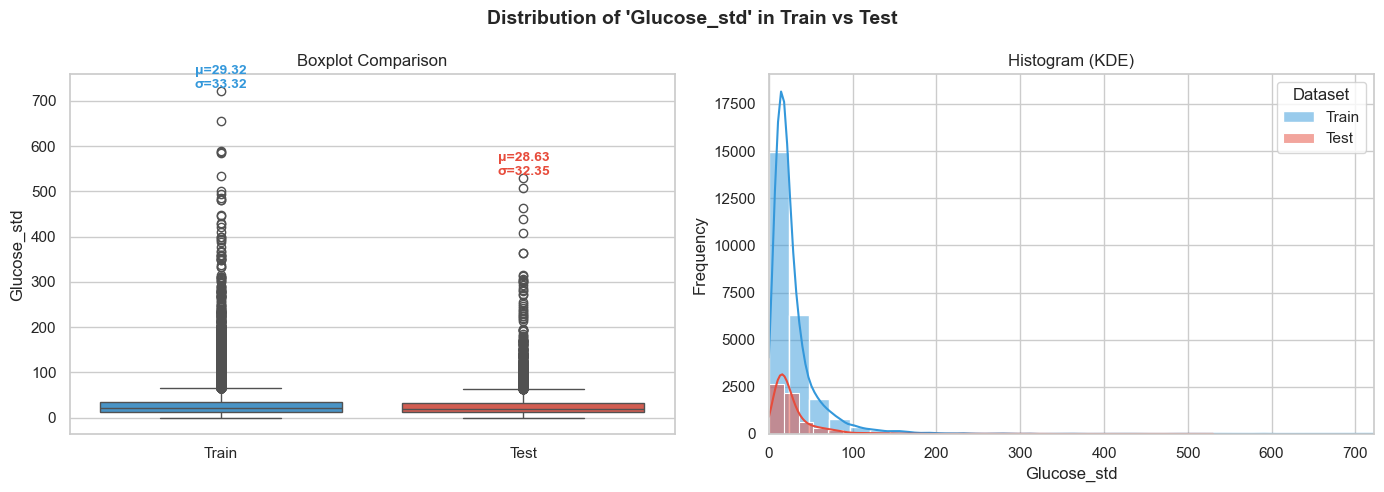

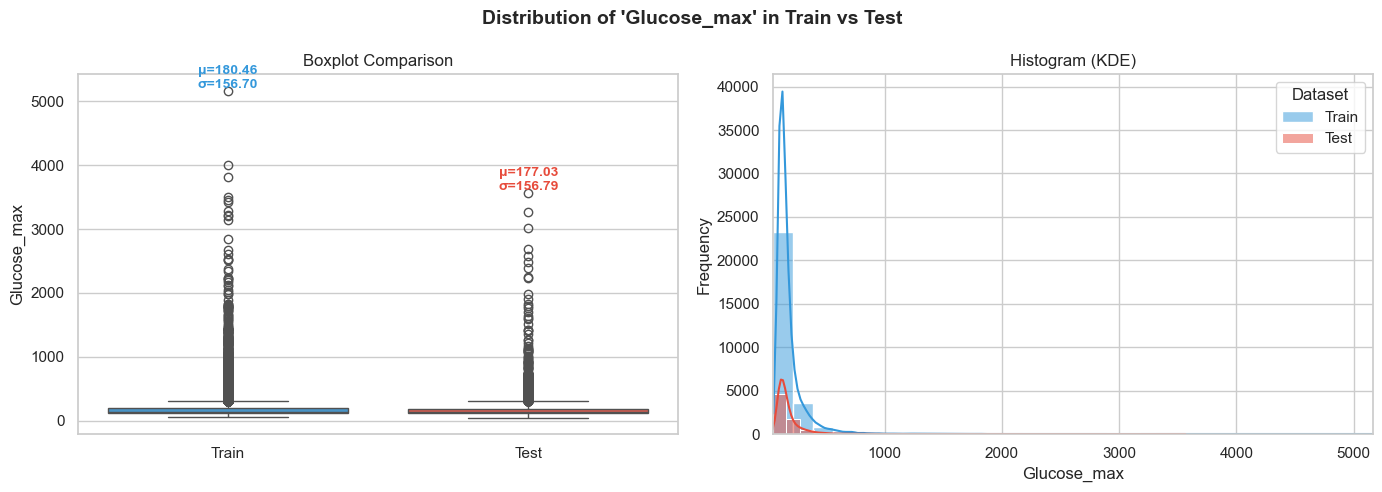

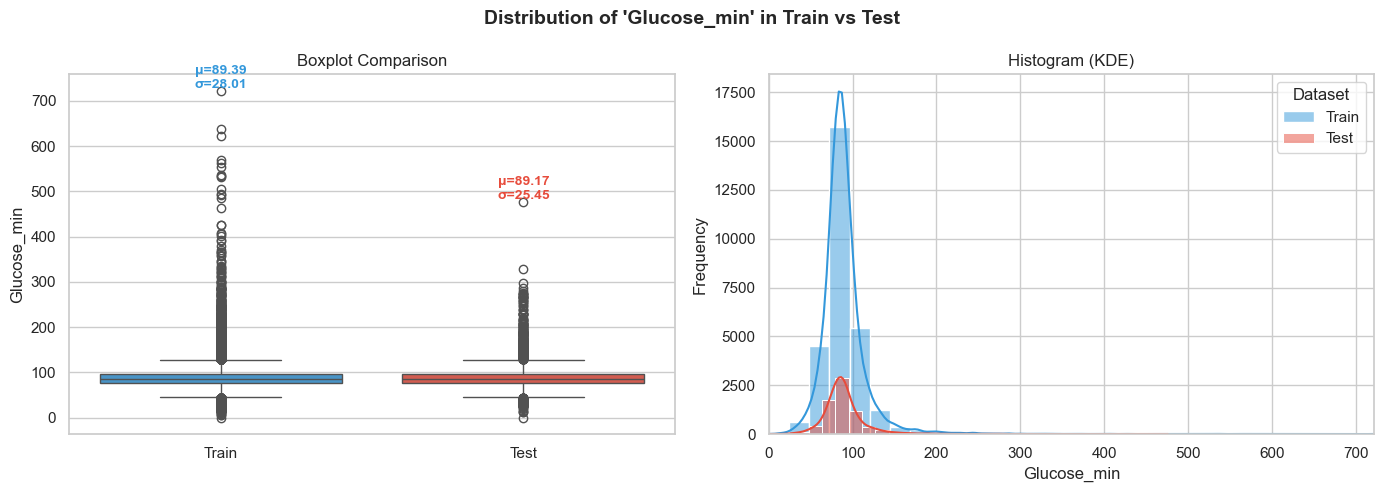

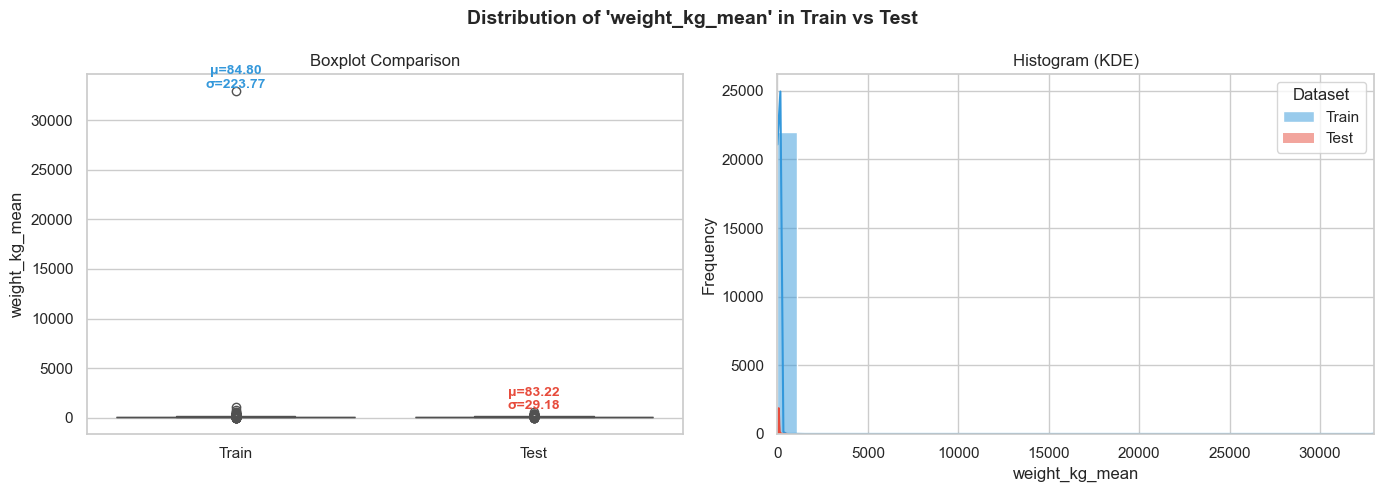

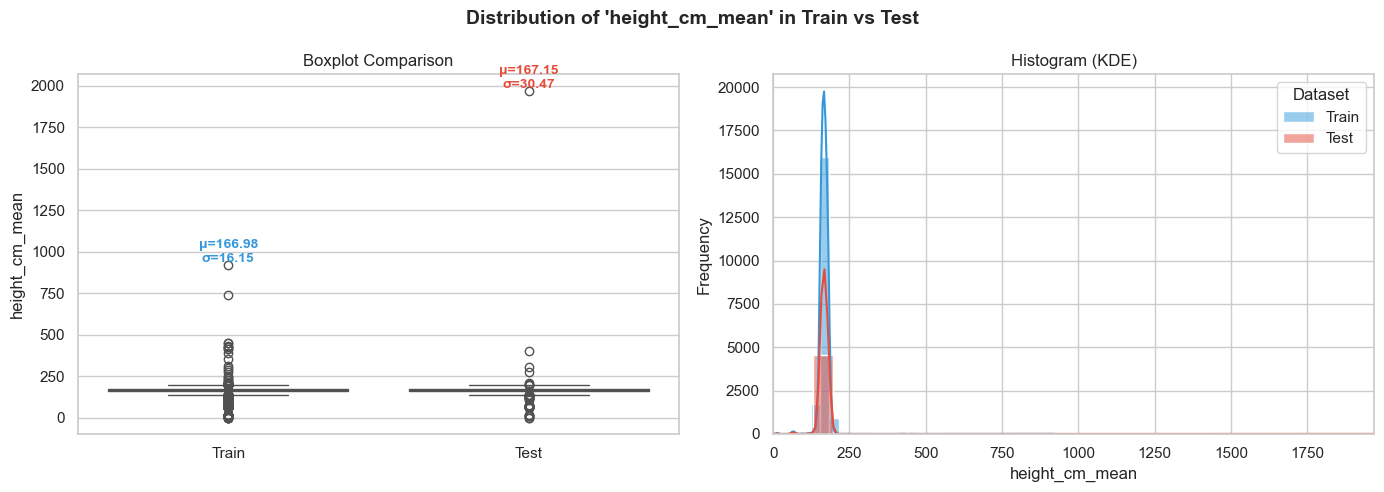

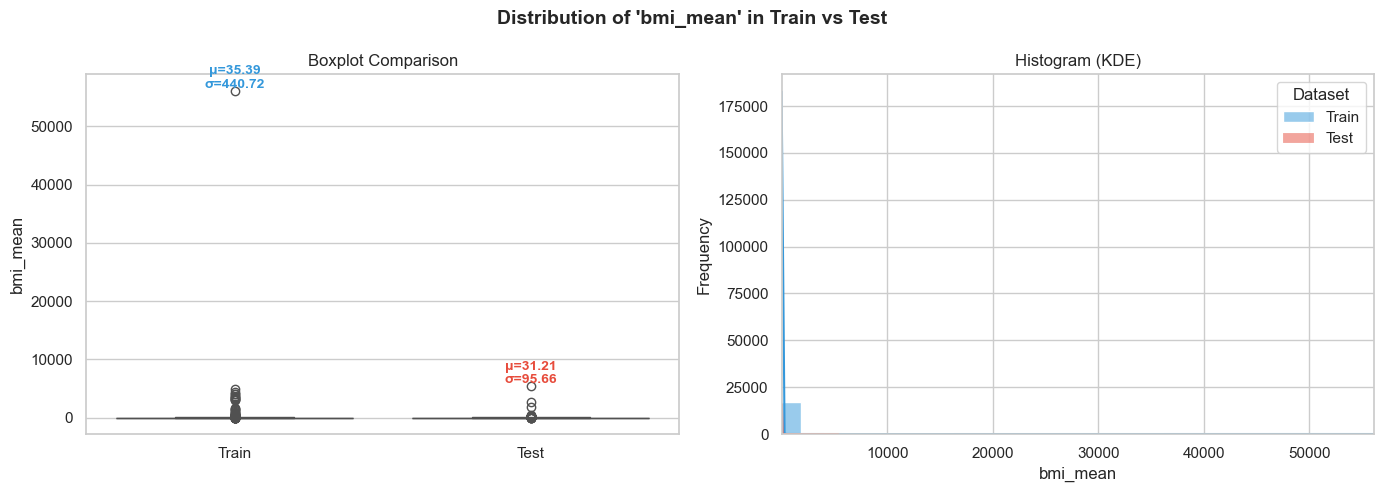

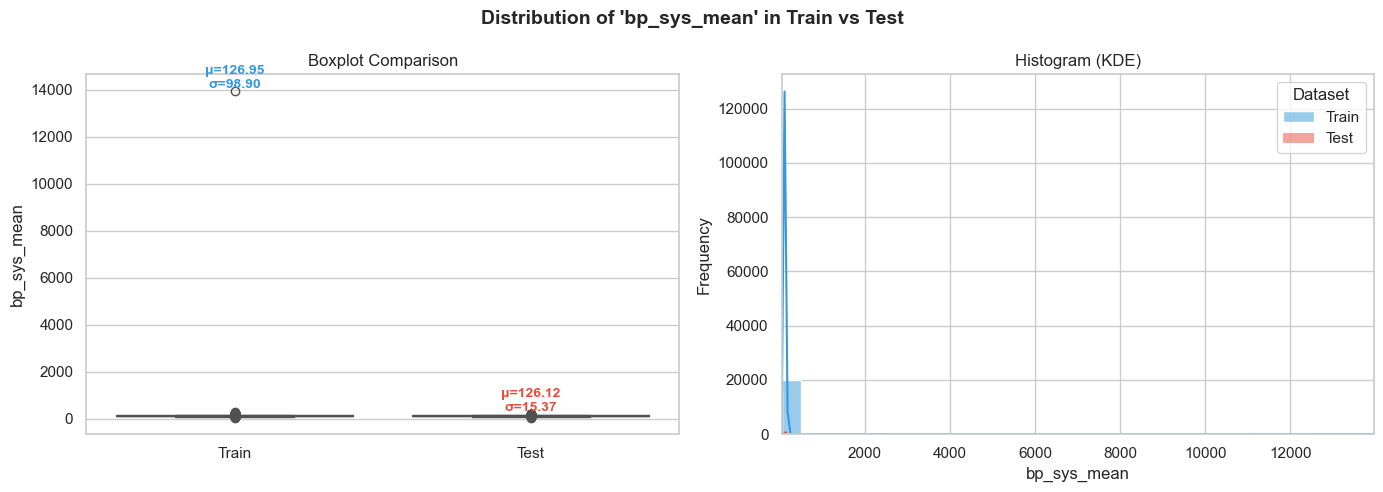

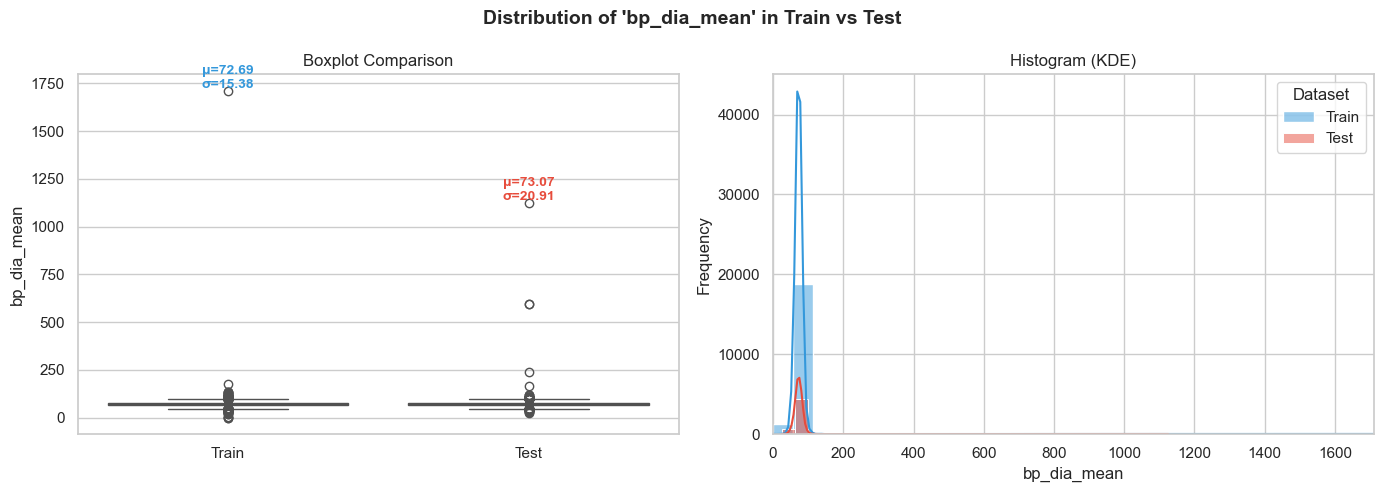

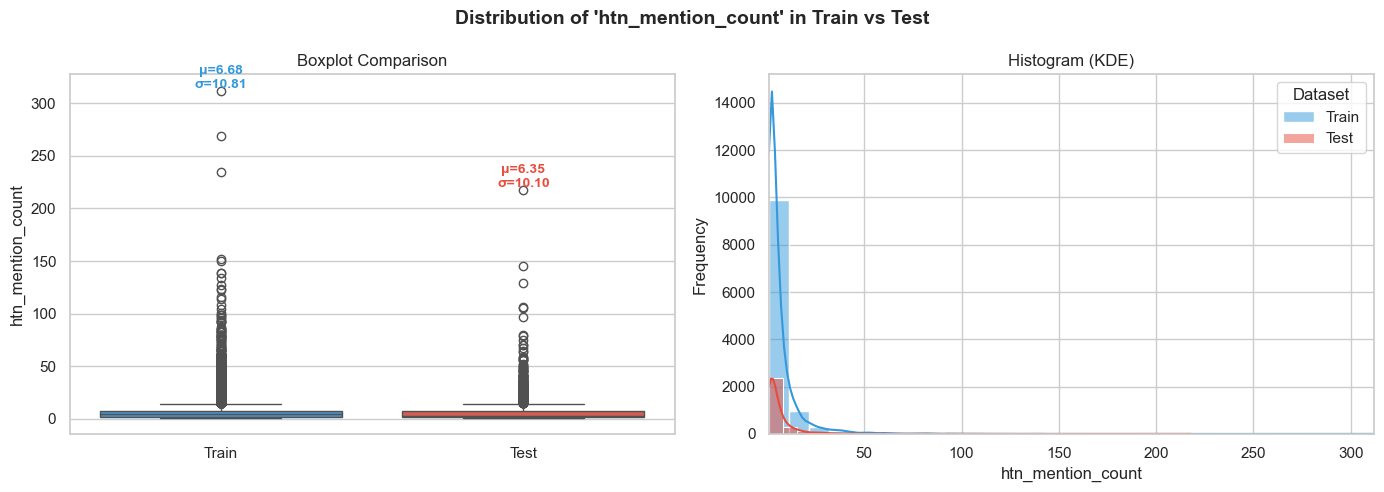

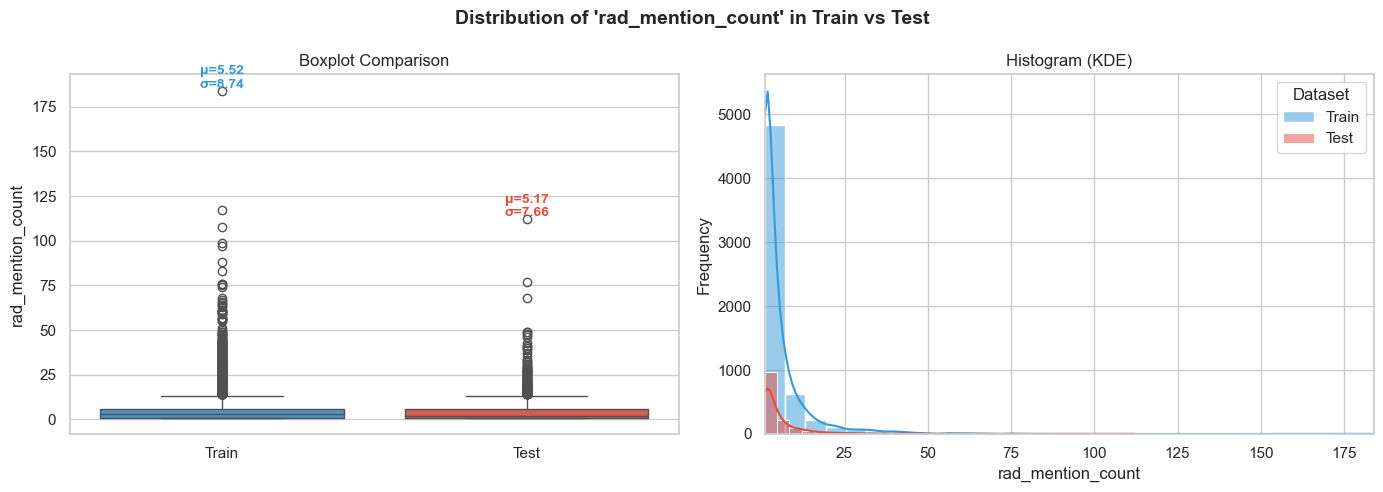

In [6]:
custom_palette = ['#3498db', '#e74c3c', '#2ecc71']

# Tag train/test for comparison
train_df['Source'] = 'Train'
test_df['Source'] = 'Test'

# Combine both for plotting
combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)

# automatically detect numeric columns if not predefined
numerical_variables = combined.select_dtypes(include=np.number).columns.tolist()
# Optionally exclude id or label columns
numerical_variables = [c for c in numerical_variables if c not in ['subject_id', 'label']]

print(f"Plotting distributions for {len(numerical_variables)} numeric features...")

def generate_feature_visualizations(feature_name):
    sns.set(style='whitegrid', font_scale=1.0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Distribution of '{feature_name}' in Train vs Test", fontsize=14, fontweight='bold')

    # Handle missing gracefully
    combined_feature = combined[[feature_name, 'Source']].dropna(subset=[feature_name])

    # ---------------------- BOX PLOT ----------------------
    sns.boxplot(
        data=combined_feature,
        x='Source', y=feature_name,
        palette=custom_palette[:2],
        ax=axes[0]
    )
    axes[0].set_title("Boxplot Comparison", fontsize=12)
    axes[0].set_xlabel("")
    axes[0].set_ylabel(feature_name)

    # Add mean & std annotations
    for source, color in zip(['Train', 'Test'], custom_palette[:2]):
        subset = combined_feature.loc[combined_feature['Source'] == source, feature_name]
        mean_val, std_val = subset.mean(), subset.std()
        axes[0].text(
            x=['Train', 'Test'].index(source),
            y=subset.max() if not np.isnan(subset.max()) else 0,
            s=f"μ={mean_val:.2f}\nσ={std_val:.2f}",
            color=color,
            fontsize=10,
            ha='center',
            va='bottom',
            fontweight='bold'
        )

    # ---------------------- HISTOGRAM ----------------------
    min_val = combined_feature[feature_name].min()
    max_val = combined_feature[feature_name].max()

    sns.histplot(
        data=combined_feature[combined_feature["Source"] == "Train"],
        x=feature_name, color=custom_palette[0],
        kde=True, bins=30, label="Train", alpha=0.5, ax=axes[1]
    )
    sns.histplot(
        data=combined_feature[combined_feature["Source"] == "Test"],
        x=feature_name, color=custom_palette[1],
        kde=True, bins=30, label="Test", alpha=0.5, ax=axes[1]
    )

    axes[1].set_xlim(min_val, max_val)
    axes[1].set_title("Histogram (KDE)", fontsize=12)
    axes[1].set_xlabel(feature_name)
    axes[1].set_ylabel("Frequency")
    axes[1].legend(title="Dataset")

    plt.tight_layout()
    plt.show()

# ---------------------- RUN FOR ALL NUMERIC FEATURES ----------------------
for feature in numerical_variables:
    generate_feature_visualizations(feature)

# Clean up added column
train_df.drop(columns=['Source'], inplace=True)
test_df.drop(columns=['Source'], inplace=True)


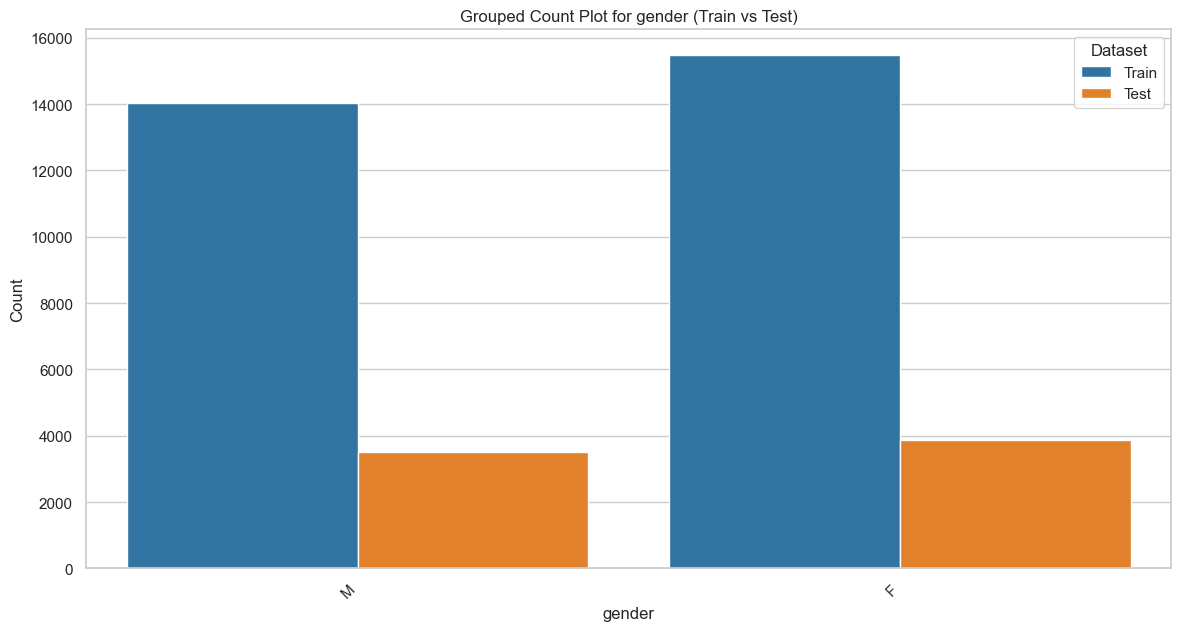

In [27]:
target_variable = 'label' 
categorical_variables = ['gender']

custom_palette = ['#1f77b4', '#ff7f0e']  

def create_grouped_countplot(variable):
    sns.set_style('whitegrid')


    train_data_copy = train_df.copy()
    test_data_copy = test_df.copy()

    train_data_copy['Dataset'] = 'Train'
    test_data_copy['Dataset'] = 'Test'

    combined_data = pd.concat([train_data_copy, test_data_copy])

    train_counts = train_df[variable].value_counts().sort_values(ascending=True).index.tolist()

    plt.figure(figsize=(14, 7))
    sns.countplot(
        data=combined_data, 
        x=variable,  
        hue="Dataset", 
        palette=custom_palette,  
        dodge=True,  
        width=0.85, 
        order=train_counts  
    )

    plt.ylabel("Count")
    plt.xlabel(variable)
    plt.title(f"Grouped Count Plot for {variable} (Train vs Test)")

    plt.xticks(rotation=45, ha="right")

    plt.show()

for variable in categorical_variables:
    create_grouped_countplot(variable)


In [7]:
if dataset == 'hosp_and_discharge':
    train_df.to_csv("../data/processed/hosp_discharge_train.csv", index=False)
    test_df.to_csv("../data/processed/hosp_discharge_test.csv", index=False)
    print("Saved hosp_discharge_train.csv and hosp_discharge_test.csv")
elif dataset == 'hosp_only':
    train_df.to_csv("../data/processed/hosp_train.csv", index=False)
    test_df.to_csv("../data/processed/hosp_test.csv", index=False)
    print("Saved hosp_train.csv and hosp_test.csv")
elif dataset == 'hosp_discharge_radio':
    train_df.to_csv("../data/processed/hosp_discharge_radio_train.csv", index=False)
    test_df.to_csv("../data/processed/hosp_discharge_radio_test.csv", index=False)
    print("Saved hosp_discharge_radio_train.csv and hosp_discharge_radio_test.csv")

Saved hosp_discharge_radio_train.csv and hosp_discharge_radio_test.csv
